# Bring your own data: embeddings from imagery you already have

<!-- <img src="https://raw.githubusercontent.com/cybergis/rs-embed/main/docs/assets/background.png" width="800" /> -->

The [playground notebook](playground.ipynb) fetches imagery from Google Earth Engine for you. This notebook is for the other situation: you **already have the pixels** — patches from your own dataset, exported GeoTIFFs, a training cube on disk — and you want foundation-model embeddings for them.

It takes four steps, and **no Earth Engine account** is needed at any point:

1. **Load** your imagery as a numpy array (here: from a GeoTIFF).
2. **Register** it as a `UserData`: the pixels plus what they are (sensor, band names, where, when).
3. **Check** which foundation models can use that data — `list_models_for_data`.
4. **Embed** — `get_embedding_from_data("galileo", data)` — and look at the result.

Then we scale the same recipe to a whole folder with `get_embeddings_batch_from_data`.

Docs: https://cybergis.github.io/rs-embed/latest/user_data/ · GitHub: https://github.com/cybergis/rs-embed · Paper: https://arxiv.org/abs/2602.23678

> Runs fine on CPU: the sample patches are small and the models used here are light. Recommended kernel: `rsembed`

Skip this if the package is already installed. `rasterio` and `matplotlib` are only used by this notebook, not by `rs-embed` itself.

In [1]:
# !pip install --upgrade rs-embed rasterio matplotlib

## 1. Load your imagery

Any array shaped `[C, H, W]` works, as long as you can say three things about it:

- **which sensor product** the pixels come from, in **raw provider units** — for Sentinel-2 L2A that is surface-reflectance DN in `0..10000`, not reflectance scaled to `0..1` (each model applies its own normalization internally, so you never do that yourself);
- **one band name per channel**;
- optionally **where** (a lon/lat footprint) and **when** (an acquisition window) it was acquired.

The sample data is eight 192 x 192 px Sentinel-2 L2A patches (12 bands, summer 2022, two sites in China) in [`data/s2_patches/`](data/s2_patches/README.md). If you cloned the repository they are already next to this notebook; otherwise the cell below downloads them.

In [1]:
import urllib.request
from pathlib import Path

DATA = Path("data/s2_patches")
FILES = [f"{site}_q{i}.tif" for site in ("shanghai", "zhejiang") for i in range(4)]

if not DATA.exists():  # running outside the repository: fetch the sample patches
    DATA.mkdir(parents=True)
    base = "https://raw.githubusercontent.com/cybergis/rs-embed/main/examples/data/s2_patches/"
    for name in FILES:
        urllib.request.urlretrieve(base + name, DATA / name)

paths = sorted(DATA.glob("*.tif"))
print(len(paths), "patches:", [p.name for p in paths])

8 patches: ['shanghai_q0.tif', 'shanghai_q1.tif', 'shanghai_q2.tif', 'shanghai_q3.tif', 'zhejiang_q0.tif', 'zhejiang_q1.tif', 'zhejiang_q2.tif', 'zhejiang_q3.tif']


Open one file and pull out the three things we need: the pixel array, the band names, and the footprint in lon/lat. Every GeoTIFF reader exposes these; `rasterio` is used here.

shanghai_q0.tif
  shape: (12, 192, 192) | dtype: uint16 | value range: 16 .. 8196
  bands: ('B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12')
  footprint (lon/lat): 121.4823, 31.2004 -> 121.4996, 31.2151


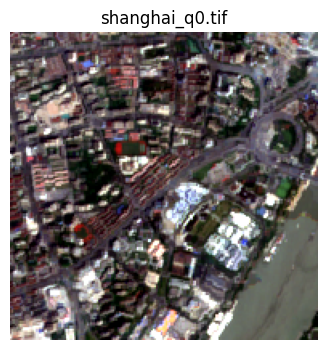

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.warp import transform_bounds

path = paths[0]
with rasterio.open(path) as src:
    pixels = src.read()                                  # numpy array, shape [C, H, W]
    bands = tuple(src.descriptions)                      # one name per channel: ("B1", "B2", ..., "B12")
    left, bottom, right, top = transform_bounds(         # footprint -> lon/lat degrees
        src.crs, "EPSG:4326", *src.bounds
    )

print(path.name)
print("  shape:", pixels.shape, "| dtype:", pixels.dtype, "| value range:", pixels.min(), "..", pixels.max())
print("  bands:", bands)
print(f"  footprint (lon/lat): {left:.4f}, {bottom:.4f} -> {right:.4f}, {top:.4f}")


def to_rgb(pixels, bands, p=(2, 98)):
    # true-colour quicklook from raw DN: pick B4/B3/B2 and stretch each channel
    img = pixels[[bands.index(b) for b in ("B4", "B3", "B2")]].transpose(1, 2, 0).astype(np.float32)
    lo, hi = np.percentile(img, p, axis=(0, 1))
    return np.clip((img - lo) / (hi - lo), 0, 1)


plt.figure(figsize=(4, 4))
plt.imshow(to_rgb(pixels, bands))
plt.title(path.name)
plt.axis("off")
plt.show()

## 2. Register it as `UserData`

This is the one new idea. A `UserData` is the pixels **plus the declaration** of what they are. The declaration — not the array shape — is what gets matched against each model:

| field        | what it says                                                       |
| ------------ | ------------------------------------------------------------------ |
| `data`       | `[C, H, W]` array in raw provider units (`[T, C, H, W]` for time series) |
| `collection` | the sensor product, e.g. `"s2"` (= `COPERNICUS/S2_SR_HARMONIZED`) or `"s1"` |
| `bands`      | one band name per channel; aliases like `"RED"` resolve to `"B4"`  |
| `spatial`    | where: a `BBox` or `PointBuffer` in lon/lat (optional, recommended) |
| `temporal`   | when: a `TemporalSpec` (optional, recommended)                     |

`spatial` and `temporal` describe *this imagery*, so they travel with the data rather than with the API call. Models that condition on geometry (`clay`, `prithvi`) refuse data without `spatial` — coordinates are never made up — and time-aware models read `temporal`.

If your data is already a numpy array (one sample from a training set, say), this is the only step you need — skip the file reading above.

In [3]:
from rs_embed import BBox, TemporalSpec, UserData

data = UserData(
    data=pixels,                         # raw S2 L2A DN, shape [12, 192, 192]
    collection="s2",
    bands=bands,                         # ("B1", "B2", ..., "B12")
    spatial=BBox(minlon=left, minlat=bottom, maxlon=right, maxlat=top),
    temporal=TemporalSpec.range("2022-06-01", "2022-09-01"),
)
data.validate()  # optional: catches a channel/band-count mismatch early
print(data.collection, data.bands, data.data.shape, data.spatial, data.temporal, sep="\n")

s2
('B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12')
(12, 192, 192)
BBox(minlon=121.48232115520851, minlat=31.200368824939485, maxlon=121.49956880866362, maxlat=31.215120643351057, crs='EPSG:4326')
TemporalSpec(mode='range', year=<function TemporalSpec.year at 0x14597e8274c0>, start='2022-06-01', end='2022-09-01')


## 3. Which foundation models can use this data?

`list_models_for_data` runs the same matching that embedding will run, for **every model in the catalog**, without loading any weights. For each model it reports whether your declaration satisfies the model's input sensor, which of your bands would be used, and — when it cannot — the exact reason.

Two things to notice in the table:

- **Superset data is fine.** One 12-band declaration serves models that need 3, 6, 10 or 12 bands: the needed channels are sliced out and reordered automatically (`bands_used`).
- **Refusals name the reason.** Precomputed models (`tessera`, `gse`, `copernicus`) have no imagery input; `satvision` wants MODIS, not Sentinel-2. Nothing is ever served silently wrong data.

In [4]:
import pandas as pd

from rs_embed import list_models_for_data
report = pd.DataFrame(list_models_for_data(data))

In [5]:
report["bands_used"] = report["bands_used"].map(lambda b: " ".join(b) if b else "")
report["reason"] = report["reason"].fillna("").str.split(";").str[0].str.slice(0, 90)

compatible = report.loc[report["compatible"], "model"].tolist()
print(len(compatible), "of", len(report), "models can embed this data:", compatible)
report.style.hide(axis="index")

16 of 20 models can embed this data: ['agrifm', 'anysat', 'clay', 'dofa', 'fomo', 'galileo', 'olmoearth', 'prithvi', 'remoteclip', 'satmae', 'satmaepp', 'scalemae', 'terrafm', 'terramind', 'thor', 'wildsat']


model,compatible,bands_used,reason
agrifm,True,B2 B3 B4 B5 B6 B7 B8 B8A B11 B12,
anysat,True,B2 B3 B4 B5 B6 B7 B8 B8A B11 B12,
clay,True,B2 B3 B4 B5 B6 B7 B8 B8A B11 B12,
copernicus,False,,Model 'copernicus' serves precomputed embeddings
dofa,True,B4 B3 B2 B5 B6 B7 B8 B11 B12,
fomo,True,B1 B2 B3 B4 B5 B6 B7 B8 B8A B9 B11 B12,
galileo,True,B2 B3 B4 B5 B6 B7 B8 B8A B11 B12,
gse,False,,Model 'gse' serves precomputed embeddings
olmoearth,True,B2 B3 B4 B8 B5 B6 B7 B8A B11 B12 B1 B9,
prithvi,True,BLUE GREEN RED NIR_NARROW SWIR_1 SWIR_2,


What if the footprint is unknown? Register without `spatial` and ask again — only the geometry-conditioned models drop out, with the reason spelled out:

In [6]:
report_nogeo = pd.DataFrame(list_models_for_data(UserData(data=pixels, collection="s2", bands=bands)))
newly_refused = report_nogeo[~report_nogeo["compatible"] & report_nogeo["model"].isin(compatible)]
for _, r in newly_refused.iterrows():
    print(f"{r['model']:8s} -> {r['reason']}")

clay     -> Model 'clay' conditions on request geometry (lat/lon or GSD encodings); it cannot embed data without UserData.spatial, and coordinates are never fabricated. Provide spatial or choose a model without this requirement (see list_models_for_data).
prithvi  -> Model 'prithvi' conditions on request geometry (lat/lon or GSD encodings); it cannot embed data without UserData.spatial, and coordinates are never fabricated. Provide spatial or choose a model without this requirement (see list_models_for_data).


## 4. Get the embedding

Now embedding takes only a model name. Two output layouts, as everywhere in `rs-embed`:

- `OutputSpec.pooled()` (default) — one vector for the whole patch: retrieval, classification, similarity.
- `OutputSpec.grid()` — a `[D, h, w]` embedding field: for when the structure *inside* the patch matters.

`emb.meta["user_input"]` records what was actually fed to the model (declared bands, bands used, channel indices), and `emb.meta["input_prep"]` how the array was sized. Patches larger than a model's native input are **tiled at full resolution and stitched**, never squashed — `galileo` sees this 192 px patch as a 3 x 3 grid of its 64 px tiles.

In [7]:
from rs_embed import OutputSpec, get_embedding_from_data

emb = get_embedding_from_data("galileo", data)                              # pooled vector
emb_grid = get_embedding_from_data("galileo", data, output=OutputSpec.grid())  # spatial field


In [8]:

print("pooled :", emb.data.shape)
print("grid   :", emb_grid.data.shape)
print("bands used      :", emb.meta["user_input"]["bands_used"])
print("channel indices :", emb.meta["user_input"]["channel_indices"])
print("input prep      :", emb.meta["input_prep"]["resolved_mode"], "| tiles:", emb.meta["input_prep"].get("tile_count"))

pooled : (128,)
grid   : (128, 24, 24)
bands used      : ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
channel indices : [1, 2, 3, 4, 5, 6, 7, 8, 10, 11]
input prep      : tile | tiles: 9


## 5. Look at it

A grid embedding has hundreds of channels, so to *see* it we project every cell onto its first three principal components and show them as RGB. Cells with similar colours have similar embeddings. Next to it, the pooled vector is just the mean of those cells.

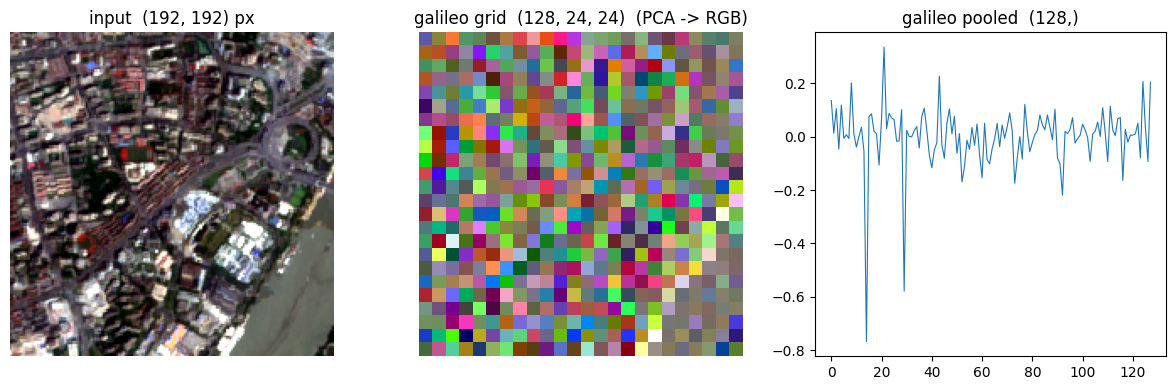

In [9]:
def pca_rgb(grid, p=(2, 98)):
    # grid: [D, h, w] -> [h, w, 3] in 0..1, first three principal components as RGB
    grid = np.asarray(grid)                      # numpy or xarray, depending on the model
    D, h, w = grid.shape
    X = grid.reshape(D, -1).T.astype(np.float64)
    X -= X.mean(axis=0)
    _, _, Vt = np.linalg.svd(X, full_matrices=False)
    Y = X @ Vt[:3].T
    lo, hi = np.percentile(Y, p, axis=0)
    return np.clip((Y - lo) / (hi - lo + 1e-8), 0, 1).reshape(h, w, 3)


fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(to_rgb(pixels, bands)); ax[0].set_title(f"input  {pixels.shape[1:]} px")
ax[1].imshow(pca_rgb(emb_grid.data)); ax[1].set_title(f"galileo grid  {emb_grid.data.shape}  (PCA -> RGB)")
ax[2].plot(emb.data, lw=0.8); ax[2].set_title(f"galileo pooled  {emb.data.shape}")
for a in ax[:2]:
    a.axis("off")
plt.tight_layout()
plt.show()

### Swap the model

Nothing else in the request changes — same `data`, a different name. Each model takes the bands it needs from the same declaration and returns its own native grid size.

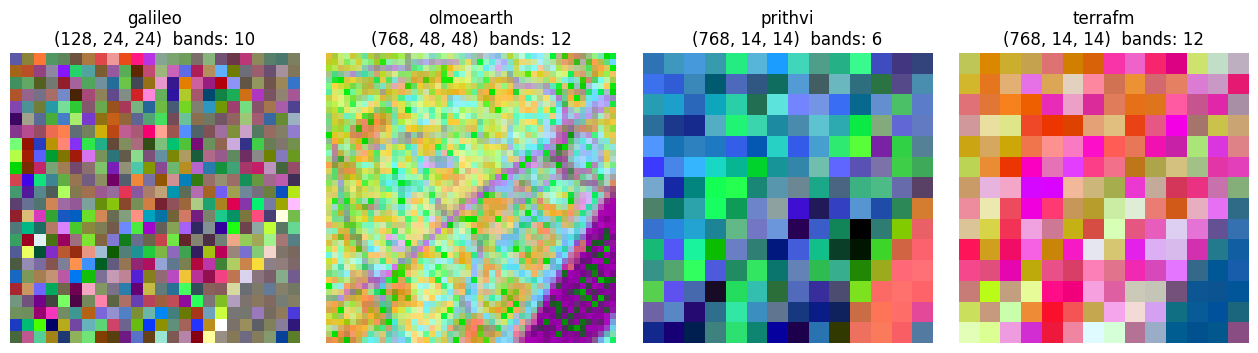

In [10]:
models = ["galileo", "olmoearth", "prithvi", "terrafm"]

fig, ax = plt.subplots(1, len(models), figsize=(3.2 * len(models), 3.4))
for a, name in zip(ax, models):
    g = get_embedding_from_data(name, data, output=OutputSpec.grid())
    a.imshow(pca_rgb(g.data))
    a.set_title(f"{name}\n{g.data.shape}  bands: {len(g.meta['user_input']['bands_used'])}")
    a.axis("off")
plt.tight_layout()
plt.show()

## 6. Your whole dataset

For a folder of patches, wrap steps 1–2 in a function and hand the list to `get_embeddings_batch_from_data`. Each item carries its own footprint (and could carry its own dates or band order); results come back in input order. `batch_size` caps how many patches reach one forward pass — lower it on a small GPU.

The result is a plain `[N, D]` feature matrix — ready for scikit-learn, clustering, retrieval, or saving to disk.

In [11]:
from rs_embed import get_embeddings_batch_from_data


def load_patch(path):
    # steps 1 + 2 for one file
    with rasterio.open(path) as src:
        left, bottom, right, top = transform_bounds(src.crs, "EPSG:4326", *src.bounds)
        return UserData(
            data=src.read(),
            collection="s2",
            bands=tuple(src.descriptions),
            spatial=BBox(minlon=left, minlat=bottom, maxlon=right, maxlat=top),
            temporal=TemporalSpec.range("2022-06-01", "2022-09-01"),
        )


datas = [load_patch(p) for p in paths]
embs = get_embeddings_batch_from_data("galileo", datas, batch_size=8)

X = np.stack([np.asarray(e.data) for e in embs])  # [N, D]
names = [p.stem for p in paths]
print("feature matrix:", X.shape)
np.save("s2_patches_galileo.npy", X)          # keep it for later

feature matrix: (8, 128)


Do the embeddings know which patches belong together? A cosine-similarity matrix says yes: the four quadrants of each site are far more similar to each other than to the other site, and the patches themselves show why.

## 7. Now with your own data

The whole recipe, condensed:

```python
data = UserData(data=array_chw, collection="s2", bands=(...), spatial=BBox(...), temporal=TemporalSpec.range(...))
[r["model"] for r in list_models_for_data(data) if r["compatible"]]   # what can I run?
emb = get_embedding_from_data("galileo", data)                         # run it
```

Things worth knowing as your data gets less tidy:

- **Units.** Pass exactly what the provider would return (S2 L2A: DN `0..10000`). Data that looks pre-scaled (max ≤ 1.5) triggers a warning, because it would otherwise produce silently wrong embeddings.
- **Band names.** `bands` may be omitted only for the canonical 12-band S2 L2A order; any other count, order, or sensor must name its bands. If your GeoTIFF has no band descriptions, write the tuple by hand.
- **Other sensors.** Sentinel-1 works the same way: `UserData(data=vv_vh, collection="s1", bands=("VV", "VH"), ...)`; for dual-branch models (`terrafm`, `olmoearth`) add `modality="s1"` to the embedding call.
- **Time series.** A `[T, C, H, W]` array is accepted by the time-series models (`galileo`, `prithvi`, `olmoearth`, `anysat`, `agrifm`); single-frame models reject it.
- **Size.** Larger-than-native patches are tiled at full resolution by default; pass `input_prep="resize"` for one-step downsampling instead. Very small patches run but carry little information — expect weak embeddings below about half a model's input size.
- **Wrong data is refused, not guessed.** A missing band, a collection mismatch, or a missing footprint for `clay`/`prithvi` raises a `ModelError` that names the problem.

Full reference: https://cybergis.github.io/rs-embed/latest/user_data/ · model input sizes and bands: https://cybergis.github.io/rs-embed/latest/models/